<a href="https://colab.research.google.com/github/ranaaa25/Air-Pollution-Analysis-/blob/main/Global_Air_Pollution_Analysis_ipynb_txt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Global Air Pollution Analysis
## CS316: Introduction to AI and Data Science Project

This presents a complete data science pipeline for predicting and classifying urban air quality levels using the Global Air Pollution Dataset. The objective is to accurately classify air quality into six categories ranging from Good to Hazardous, identify the key pollutants driving poor air quality, and derive actionable insights that contribute to healthier urban environments.

**SDG Alignment:** SDG 3 (Good Health and Well-Being) and SDG 11 (Sustainable Cities and Communities)for teh

---
## Step 1: Import Require Libraries

We import the essential Python libraries.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
%pip install scikit-learn


---
## Step 2: Load the Dataset

We load the Global Air Pollution Dataset from a CSV file.

In [ ]:
df = pd.read_csv('global_air_pollution_dataset.csv')
print("Dataset shape:")
df.shape

Dataset shape:


(23463, 12)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


---
## Step 3: Initial Data Exploration

### 3.1 View First Few Records

In [ ]:
print("First 5 records of the dataset:")
df.head()

First 5 records of the dataset:


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
0,Russian Federation,Praskoveya,51,Moderate,1,Good,36,Good,0,Good,51,Moderate
1,Brazil,Presidente Dutra,41,Good,1,Good,5,Good,1,Good,41,Good
2,Italy,Priolo Gargallo,66,Moderate,1,Good,39,Good,2,Good,66,Moderate
3,Poland,Przasnysz,34,Good,1,Good,34,Good,0,Good,20,Good
4,France,Punaauia,22,Good,0,Good,22,Good,0,Good,6,Good


### 3.2 View Last Few Records

In [ ]:
print("Last 5 records of the dataset:")
df.tail()

Last 5 records of the dataset:


,Country,City,AQI Value,AQI Category,CO AQI Value,CO AQI Category,Ozone AQI Value,Ozone AQI Category,NO2 AQI Value,NO2 AQI Category,PM2.5 AQI Value,PM2.5 AQI Category
23458,India,Gursahaiganj,184,Unhealthy,3,Good,154,Unhealthy,2,Good,184,Unhealthy
23459,France,Sceaux,50,Good,1,Good,20,Good,5,Good,50,Good
23460,India,Mormugao,50,Good,1,Good,22,Good,1,Good,50,Good
23461,United States of America,Westerville,71,Moderate,1,Good,44,Good,2,Good,71,Moderate
23462,Malaysia,Marang,70,Moderate,1,Good,38,Good,0,Good,70,Moderate


### 3.3 Check for Duplicate Records

In [ ]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate records:")
duplicate_count

Number of duplicate records:


np.int64(0)

### 3.4 Dataset Shape and Dimensions

In [ ]:
print(f"Dataset shape: {df.shape}")
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Dataset shape: (23463, 12)
Number of rows: 23463
Number of columns: 12


### 3.5 Data Types and Info

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23463 entries, 0 to 23462
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country             23036 non-null  object
 1   City                23462 non-null  object
 2   AQI Value           23463 non-null  int64 
 3   AQI Category        23463 non-null  object
 4   CO AQI Value        23463 non-null  int64 
 5   CO AQI Category     23463 non-null  object
 6   Ozone AQI Value     23463 non-null  int64 
 7   Ozone AQI Category  23463 non-null  object
 8   NO2 AQI Value       23463 non-null  int64 
 9   NO2 AQI Category    23463 non-null  object
 10  PM2.5 AQI Value     23463 non-null  int64 
 11  PM2.5 AQI Category  23463 non-null  object
dtypes: int64(5), object(7)
memory usage: 2.1+ MB


### 3.6 Descriptive Statistics

In [ ]:
print("Descriptive Statistics:")
df.describe()

Descriptive Statistics:


,AQI Value,CO AQI Value,Ozone AQI Value,NO2 AQI Value,PM2.5 AQI Value
count,23463.000000,23463.000000,23463.000000,23463.000000,23463.000000
mean,72.010868,1.368367,35.193709,3.063334,68.519755
std,56.055220,1.832064,28.098723,5.254108,54.796443
min,6.000000,0.000000,0.000000,0.000000,0.000000
25%,39.000000,1.000000,21.000000,0.000000,35.000000
50%,55.000000,1.000000,31.000000,1.000000,54.000000
75%,79.000000,1.000000,40.000000,4.000000,79.000000
max,500.000000,133.000000,235.000000,91.000000,500.000000


---
## Step 4: Data Cleaning and Preprocessing

### 4.1 Check for Missing Values

In [ ]:
print("Missing values in each column:")
df.isnull().sum()

Missing values in each column:


,0
Country,427
City,1
AQI Value,0
AQI Category,0
CO AQI Value,0
CO AQI Category,0
Ozone AQI Value,0
Ozone AQI Category,0
NO2 AQI Value,0
NO2 AQI Category,0


### 4.2 Drop Irrelevant Columns

We didnt fill the missing country and city columns because it would be better if we completely dropped city and country. We drop `City` because it has too many unique values (23,462) and `Country` as geographic labels dont directly determine air quality. Cities within the same country can have vastly different pollution levels.
We also drop `CO AQI Category` and `NO2 AQI Category` as over 99.9% of their values are 'Good', making them uninformative for classification.

In [ ]:
# Drop columns with low discriminatory value
df = df.drop(columns=['City', 'Country', 'CO AQI Category', 'NO2 AQI Category'])

print("Remaining columns:")
print(df.columns.tolist())
print(f"\nDataset shape: {df.shape}")

Remaining columns:
['AQI Value', 'AQI Category', 'CO AQI Value', 'Ozone AQI Value', 'Ozone AQI Category', 'NO2 AQI Value', 'PM2.5 AQI Value', 'PM2.5 AQI Category']

Dataset shape: (23463, 8)


### 4.3 One-Hot Encoding of Categorical Columns

We convert the remaining categorical AQI category columns into numeric format using one-hot encoding so they can be used by machine learning models.

In [ ]:
# Apply one-hot encoding to categorical columns (excluding the target column)
categorical_cols = ['Ozone AQI Category', 'PM2.5 AQI Category']
df = pd.get_dummies(df, columns=categorical_cols)

### 4.4 Outlier Detection

We used the IQR method to detect outliers in the numerical AQI columns.The outliers detected represent extreme pollution events in certain cities. the outliers are the most critical cases for our SDG goals as the "hazardous" cities are the ones twhere intervention is most needed.

In [ ]:
# Check for outliers using IQR method
numerical_cols = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']

print("Outlier Detection using IQR Method:")
print("=" * 50)
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers detected")

Outlier Detection using IQR Method:
AQI Value: 2935 outliers detected
CO AQI Value: 8596 outliers detected
Ozone AQI Value: 1513 outliers detected
NO2 AQI Value: 1681 outliers detected
PM2.5 AQI Value: 2641 outliers detected


---
## Step 5: Exploratory Data Analysis (EDA)

### 5.1 AQI Category Distribution (Bar Chart)

We analyze the distribution of the overall air quality index category, whis is our target variable.

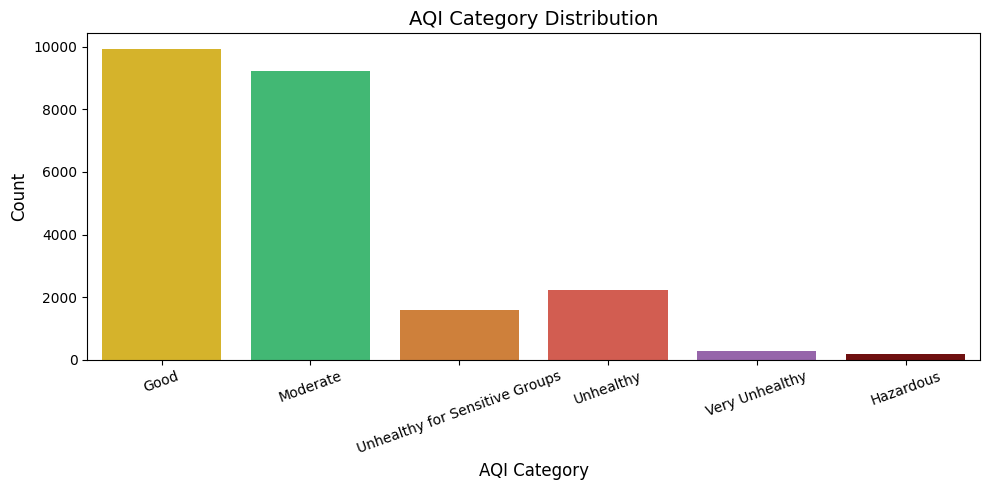


Value counts for AQI Category:
AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(10, 5))
plt.title('AQI Category Distribution', fontsize=14)

order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6', '#7f0000']

sns.countplot(x='AQI Category', data=df, order=order, hue='AQI Category', palette=colors, legend=False)
plt.xlabel('AQI Category', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks(rotation=20, fontsize=10)
plt.tight_layout()
plt.show()

print("\nValue counts for AQI Category:")
print(df['AQI Category'].value_counts())

### 5.2 Distribution of AQI Values (Histogram)

We examine the distribution of the overall AQI value across all cities.

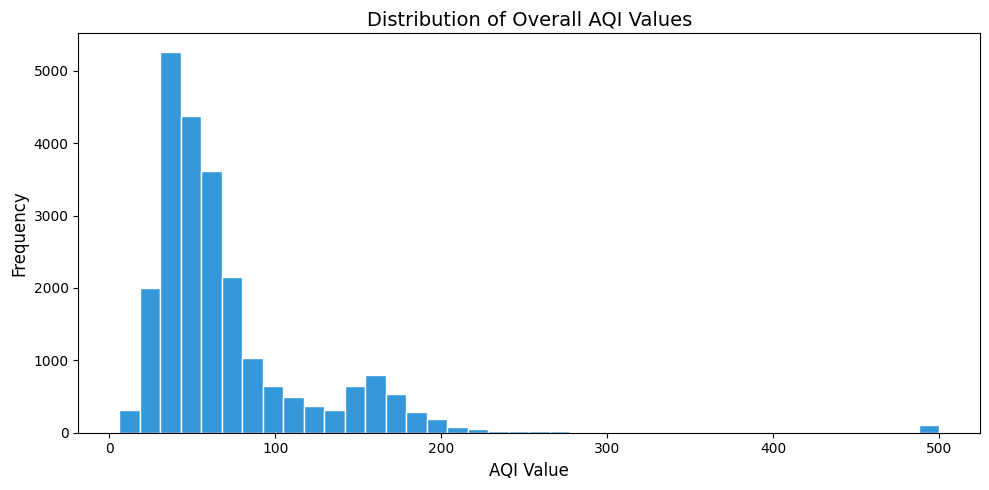

Mean AQI: 72.01
Median AQI: 55.00
Std AQI: 56.06


In [ ]:
plt.figure(figsize=(10, 5))
plt.title('Distribution of Overall AQI Values', fontsize=14)
plt.hist(df['AQI Value'], bins=40, color='#3498db', edgecolor='white')
plt.xlabel('AQI Value', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.tight_layout()
plt.show()

print(f"Mean AQI: {df['AQI Value'].mean():.2f}")
print(f"Median AQI: {df['AQI Value'].median():.2f}")
print(f"Std AQI: {df['AQI Value'].std():.2f}")

### 5.3 Per-Pollutant AQI Distribution (Box Plots)

We compare the distribution of each pollutant AQI value to understand which pollutants contribute most to poor air quality.

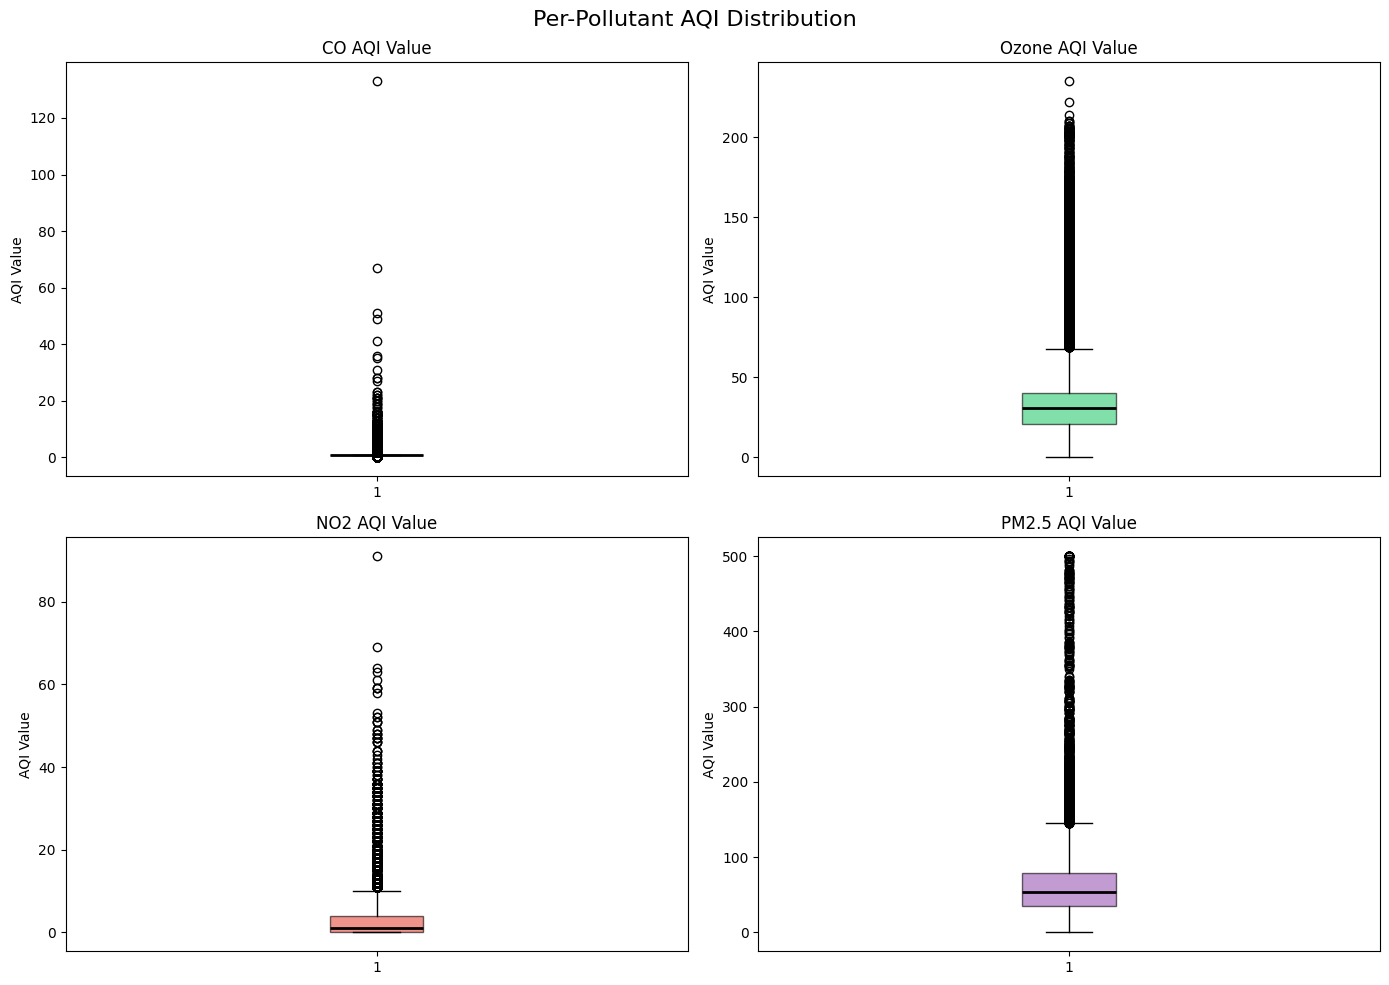

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Per-Pollutant AQI Distribution', fontsize=16)

pollutants = ['CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for ax, col, color in zip(axes.flatten(), pollutants, colors):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color='black', linewidth=2))
    ax.set_title(col, fontsize=12)
    ax.set_ylabel('AQI Value', fontsize=10)

plt.tight_layout()
plt.show()

PM2.5 has the widest spread and the most extreme outliers among all pollutants, confirming its dominant role in driving overall AQI values. CO and NO2 are concentrated at very low values across most cities, while Ozone shows moderate variability.

### 5.4 PM2.5 vs Overall AQI (Scatter Plot)

We examine the relationship between PM2.5 AQI value and the overall AQI value.

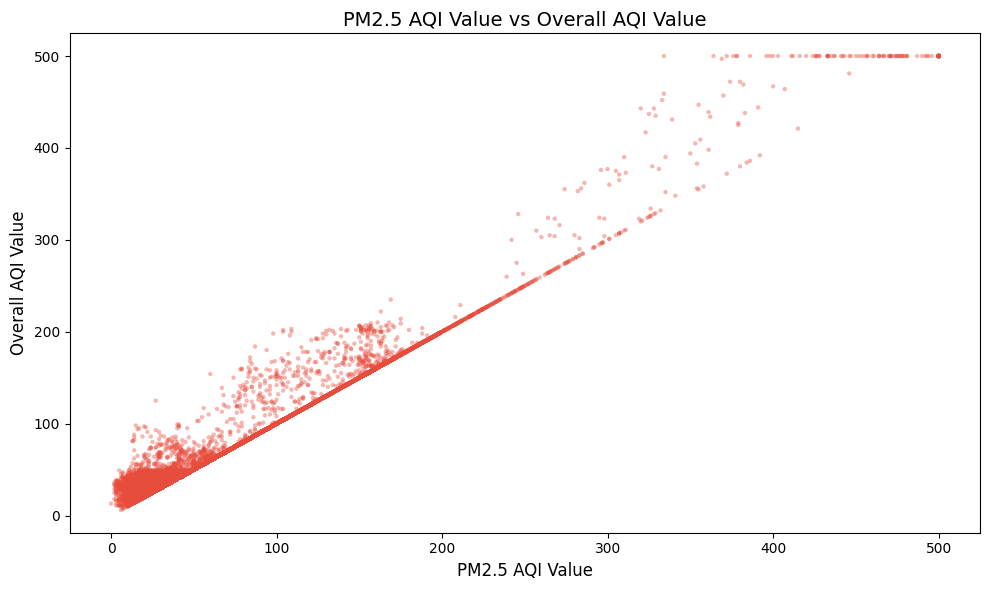

Correlation between PM2.5 AQI and Overall AQI: 0.984


In [ ]:
plt.figure(figsize=(10, 6))
plt.title('PM2.5 AQI Value vs Overall AQI Value', fontsize=14)
plt.scatter(df['PM2.5 AQI Value'], df['AQI Value'], alpha=0.4, color='#e74c3c', edgecolors='none', s=10)
plt.xlabel('PM2.5 AQI Value', fontsize=12)
plt.ylabel('Overall AQI Value', fontsize=12)
plt.tight_layout()
plt.show()

correlation = df['PM2.5 AQI Value'].corr(df['AQI Value'])
print(f"Correlation between PM2.5 AQI and Overall AQI: {correlation:.3f}")

a near-perfect positive correlation (r = 0.984) between PM2.5 AQI and the overall AQI value. This confirms that PM2.5 is the dominant pollutant driving air quality classifications globally.

### 5.5 Correlation Heatmap

We examine the correlations between all numerical features to identify relationships and potential multicollinearity.

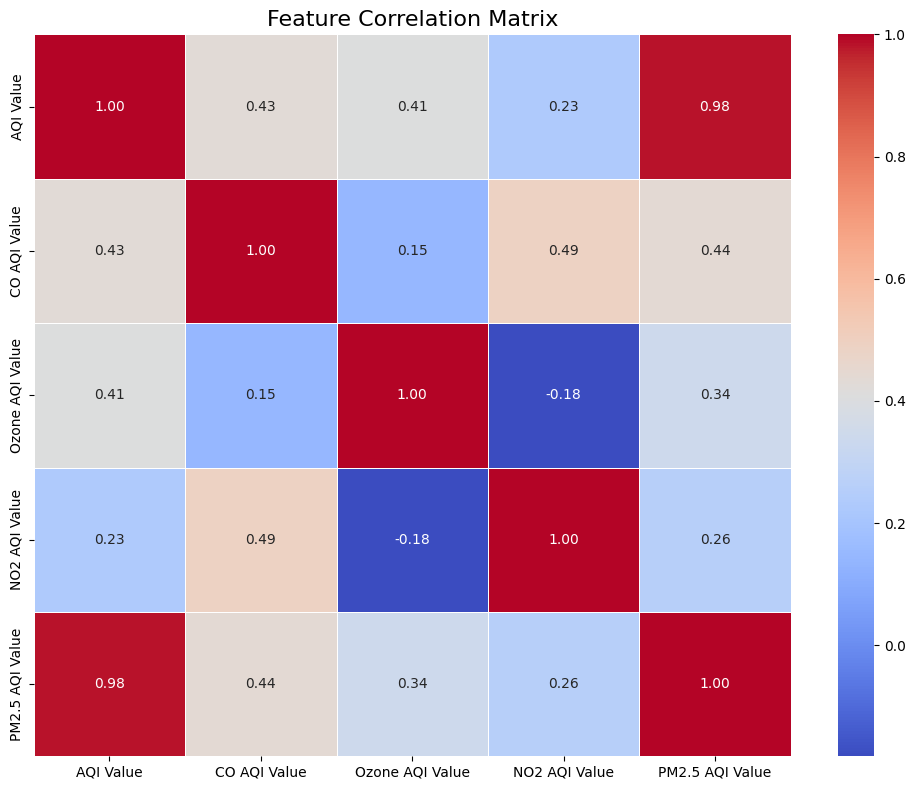

In [ ]:
# Select only the original numerical columns for correlation analysis
numerical_cols = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

PM2.5 shows an extremely strong correlation with the overall AQI (0.98). CO and Ozone show moderate correlations with the overall AQI, while NO2 shows a weaker relationship. The low correlations between pollutants themselves suggest that each pollutant provides independent information.

### 5.6 Pairplot

We visualize the relationships between all numerical variables, colored by AQI category.

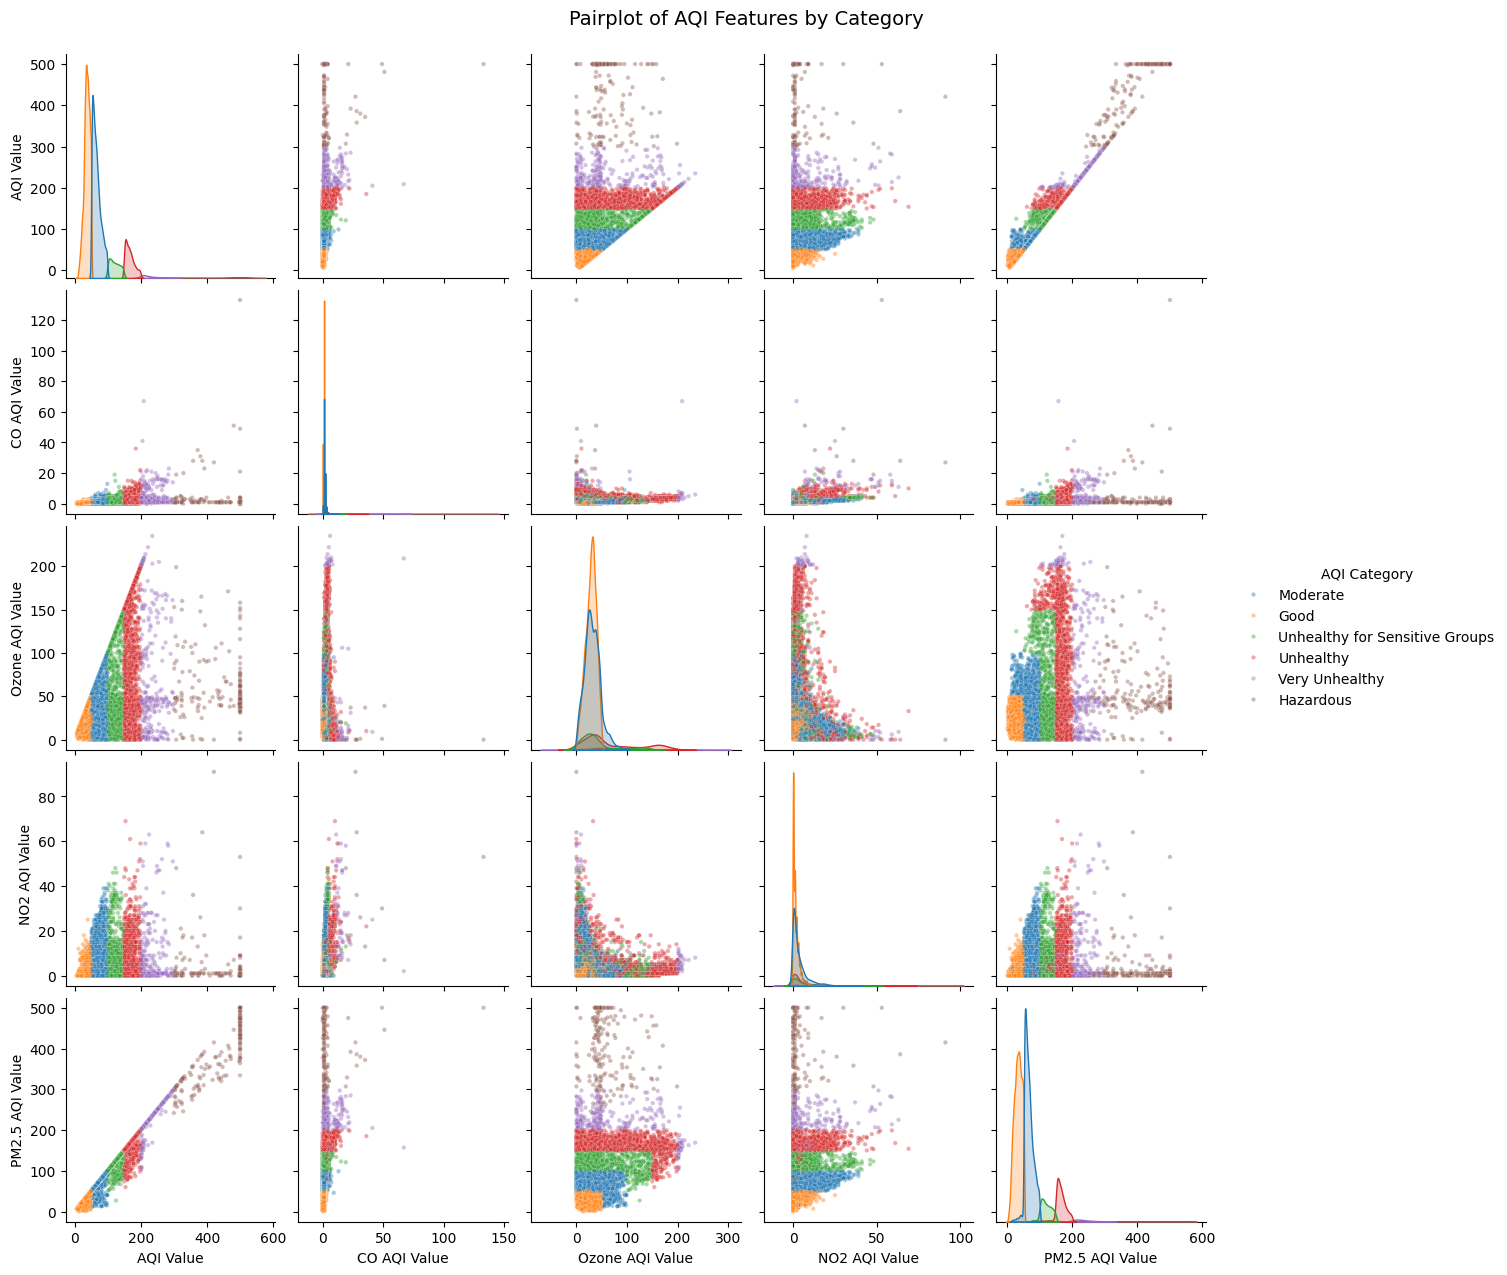

In [ ]:
pairplot_cols = ['AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value', 'AQI Category']

#we need to check it before the one-hot encoding for pairplot
df_original = pd.read_csv('global_air_pollution_dataset.csv').dropna()

sns.pairplot(df_original[pairplot_cols], hue='AQI Category', plot_kws={'alpha': 0.4, 's': 10})
plt.suptitle('Pairplot of AQI Features by Category', y=1.02, fontsize=14)
plt.show()

The pairplot reveals clear separation between AQI categories, particularly along the PM2.5 axis. Cities labeled 'Hazardous' and 'Very Unhealthy' cluster at high PM2.5 values, while 'Good' cities cluster at the lower end. This confirms that PM2.5 is the most discriminative feature for classification.

### 5.7 Violin Plot — AQI Value Distribution by Category

The violin plot shows the full distribution shape of AQI values within each category.

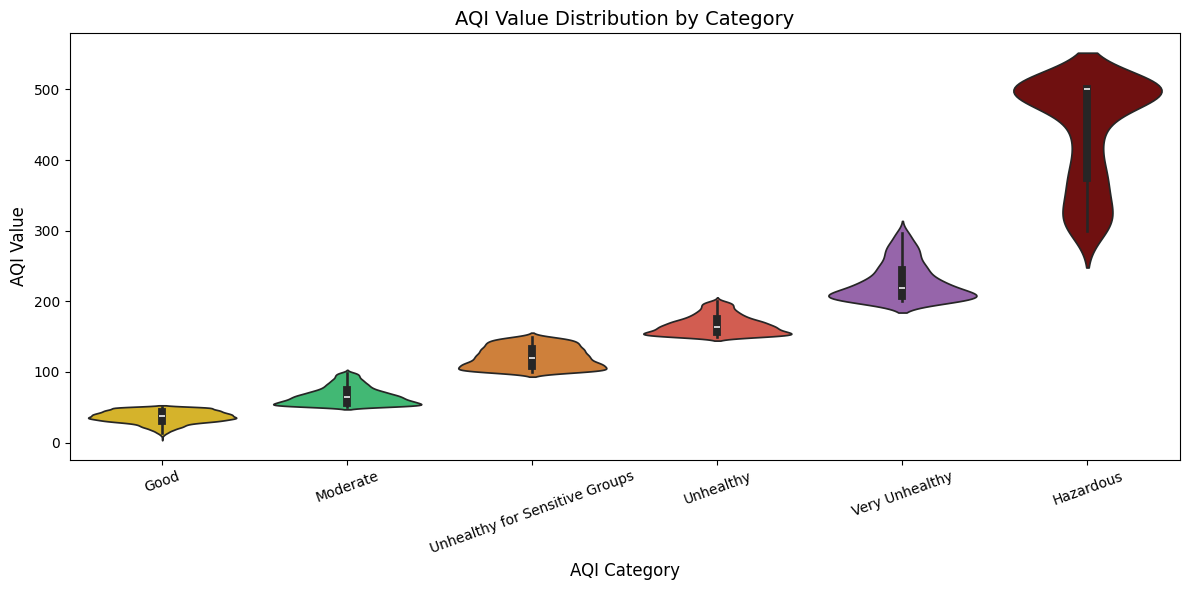

In [ ]:
plt.figure(figsize=(12, 6))
plt.title('AQI Value Distribution by Category', fontsize=14)

order = ['Good', 'Moderate', 'Unhealthy for Sensitive Groups', 'Unhealthy', 'Very Unhealthy', 'Hazardous']
sns.violinplot(x='AQI Category', y='AQI Value', data=df_original, order=order,
               hue='AQI Category', palette=['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#9b59b6', '#7f0000'],
               legend=False)

plt.xlabel('AQI Category', fontsize=12)
plt.ylabel('AQI Value', fontsize=12)
plt.xticks(rotation=20, fontsize=10)
plt.tight_layout()
plt.show()

The violin plot confirms that AQI categories are well-separated with minimal overlap, indicating that the classification task should be tractable for machine learning models. The 'Hazardous' category shows the widest spread, reflecting the variability of extreme pollution events.

### 5.8 Group Statistics by AQI Category

We compute the mean pollutant values for each AQI category to understand how each pollutant contributes to different levels of air quality.

In [ ]:
# Group by AQI Category and compute mean values
group_cols = ['AQI Category', 'AQI Value', 'CO AQI Value', 'Ozone AQI Value', 'NO2 AQI Value', 'PM2.5 AQI Value']
grouped = df_original[group_cols].groupby('AQI Category').mean()

print("Mean Pollutant Values by AQI Category:")
print("=" * 60)
print(grouped.round(2))

Mean Pollutant Values by AQI Category:
                                AQI Value  CO AQI Value  Ozone AQI Value  \
AQI Category                                                               
Good                                36.51          0.77            28.26   
Hazardous                          440.94          3.74            58.49   
Moderate                            66.46          1.30            31.24   
Unhealthy                          166.73          3.09            69.04   
Unhealthy for Sensitive Groups     121.20          2.15            41.90   
Very Unhealthy                     228.17          5.24            84.56   

                                NO2 AQI Value  PM2.5 AQI Value  
AQI Category                                                    
Good                                     1.48            31.67  
Hazardous                                3.76           400.20  
Moderate                                 3.65            65.47  
Unhealthy                  

As the AQI category worsens from 'Good' to 'Hazardous', PM2.5 values increase dramatically, confirming its role as the primary driver of air quality classification. CO, Ozone, and NO2 also increase but at a much lower rate.

---
## Step 6: Prepare Data for Modeling

We separate features and the target variable, and verify the final cleaned dataset is ready for model training.

In [ ]:
# Separate features (X) and target (y)

X = df.drop(columns=['AQI Category'])
y = df['AQI Category']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nTarget classes: {y.unique()}")
print(f"\nClass distribution:")
print(y.value_counts())

Features shape: (23463, 16)
Target shape: (23463,)

Target classes: ['Moderate' 'Good' 'Unhealthy for Sensitive Groups' 'Unhealthy'
 'Very Unhealthy' 'Hazardous']

Class distribution:
AQI Category
Good                              9936
Moderate                          9231
Unhealthy                         2227
Unhealthy for Sensitive Groups    1591
Very Unhealthy                     287
Hazardous                          191
Name: count, dtype: int64


## Step 7: Logistic Regression Model
In this step, we start building our first classification model. We use Logistic Regression to predict the AQI category based on the pollutant-related features prepared earlier.

First, we divide the dataset into training and testing data.  
The training set is used to teach the model, and the testing set is used later to check how well it performs on unseen data.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (18770, 16)
Test shape: (4693, 16)


Next, we train the Logistic Regression model using the training data.  
This will allow the model to learn the relationship between pollutant values and AQI categories.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train the Logistic Regression model
model = LogisticRegression(max_iter=2000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")

Model trained successfully.


After training the model, we use it to make predictions on the test set.  
These predicted values will then be compared with the actual AQI categories.

In [ ]:
# Use the trained model to predict AQI categories
y_pred = model.predict(X_test_scaled)

print("Predictions completed.")

Predictions completed.


Finally, we evaluate the model using common classification metrics.  
We use accuracy to measure overall performance, the confusion matrix to see where the model makes mistakes, and the classification report to examine precision, recall, and F1-score for each category.

In [ ]:

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
report = classification_report(y_test, y_pred)

print("Accuracy:", round(accuracy, 4))
print("\nConfusion Matrix:\n")
print(cm)
print("\nClassification Report:\n")
print(report)

Accuracy: 0.9998

Confusion Matrix:

[[1987    0    0    0    0    0]
 [   0   37    0    0    0    1]
 [   0    0 1846    0    0    0]
 [   0    0    0  446    0    0]
 [   0    0    0    0  318    0]
 [   0    0    0    0    0   58]]

Classification Report:

                                precision    recall  f1-score   support

                          Good       1.00      1.00      1.00      1987
                     Hazardous       1.00      0.97      0.99        38
                      Moderate       1.00      1.00      1.00      1846
                     Unhealthy       1.00      1.00      1.00       446
Unhealthy for Sensitive Groups       1.00      1.00      1.00       318
                Very Unhealthy       0.98      1.00      0.99        58

                      accuracy                           1.00      4693
                     macro avg       1.00      1.00      1.00      4693
                  weighted avg       1.00      1.00      1.00      4693



### Interpretation
The Logistic Regression model gives us an initial baseline for AQI classification.  
Since some pollutant features, especially PM2.5, show a strong relationship with AQI, we expect the model to perform reasonably well.

## Step 8: Top 10 Most Polluted Countries
To add one more meaningful visualization, we go back to the original dataset and identify the countries with the highest average AQI values.

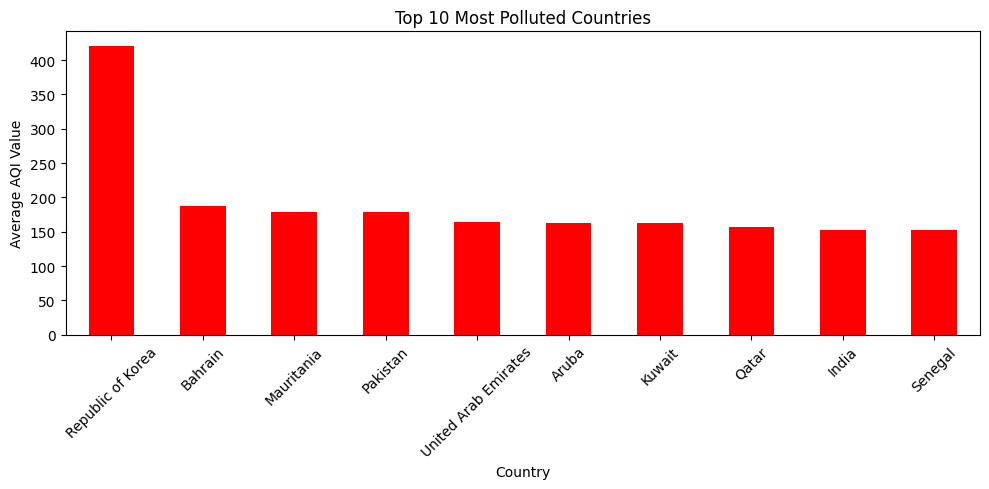

In [ ]:
# Reload the original dataset to use the Country column again
df_country = pd.read_csv('global_air_pollution_dataset.csv')

# Calculate the average AQI value for each country
top_countries = df_country.groupby('Country')['AQI Value'].mean().sort_values(ascending=False).head(10)

# Plot the top 10 countries with the highest average AQI
top_countries.plot(kind='bar', figsize=(10, 5), color='red')
plt.title("Top 10 Most Polluted Countries")
plt.xlabel("Country")
plt.ylabel("Average AQI Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

This graph helps show which countries appear at the top in terms of average pollution levels in the dataset.  
It adds a broader geographic view to the analysis.

## Step 9: Additional Analysis and Modeling

In this step, we perform additional visualizations and build a Random Forest model to further analyze air quality patterns and compare model performance.

### Step 9.1: PM2.5 vs AQI Analysis

We explore the relationship between PM2.5 levels and the overall AQI using a scatter plot to understand how strongly PM2.5 affects air quality.


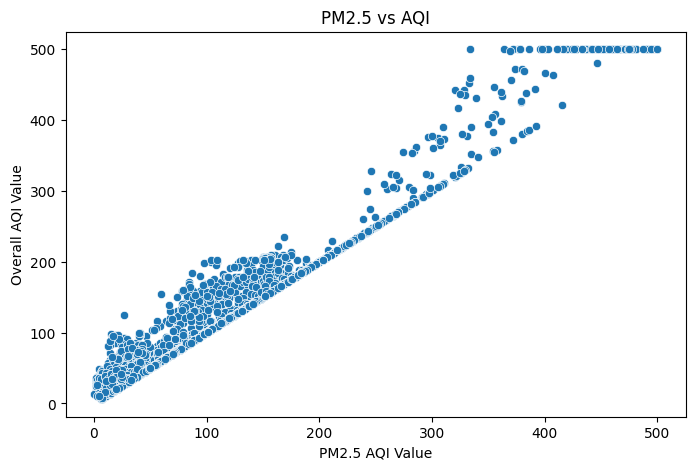

Correlation: 0.984


In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['PM2.5 AQI Value'], y=df['AQI Value'])

plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5 AQI Value")
plt.ylabel("Overall AQI Value")

plt.show()

correlation = df['PM2.5 AQI Value'].corr(df['AQI Value'])
print("Correlation:", round(correlation, 3))


The scatter plot shows a strong positive relationship between PM2.5 and AQI values. As PM2.5 increases, the overall AQI also increases.

This confirms that PM2.5 is a major contributor to air pollution and plays a significant role in determining air quality levels.

### Step 9.2: AQI Distribution per Category

We use a violin plot to visualize how AQI values are distributed across different categories. This helps us understand the spread and density of values.

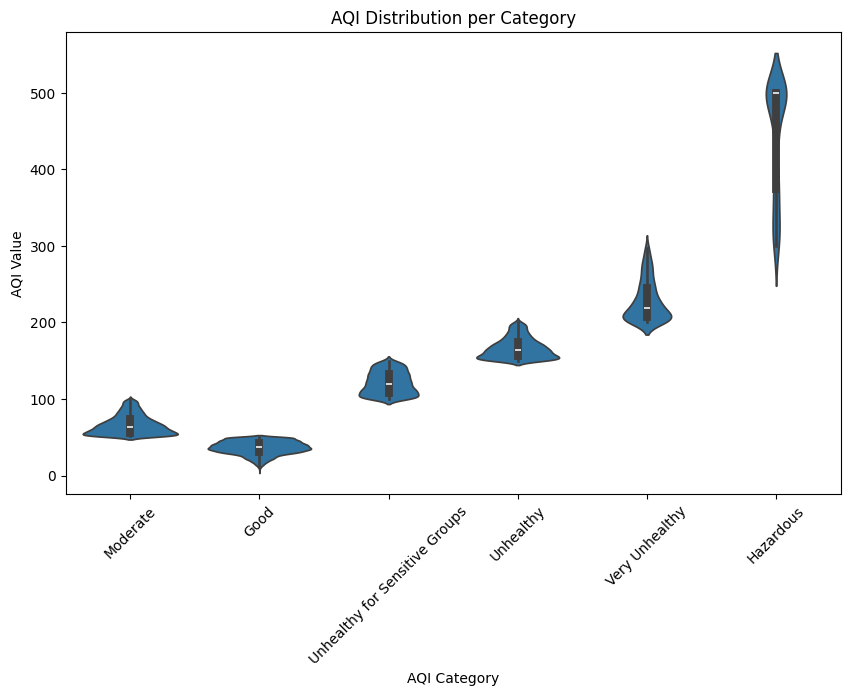

In [ ]:
plt.figure(figsize=(10,6))
sns.violinplot(x=df['AQI Category'], y=df['AQI Value'])

plt.title("AQI Distribution per Category")
plt.xticks(rotation=45)

plt.show()

The violin plot shows clear separation between AQI categories. Lower categories have lower AQI values, while higher categories show higher and more spread values.

This indicates that the dataset is well-structured for classification tasks.

### Step 9.3: Distribution Analysis

We analyze the distribution of AQI and PM2.5 values to understand their spread and identify extreme pollution levels.

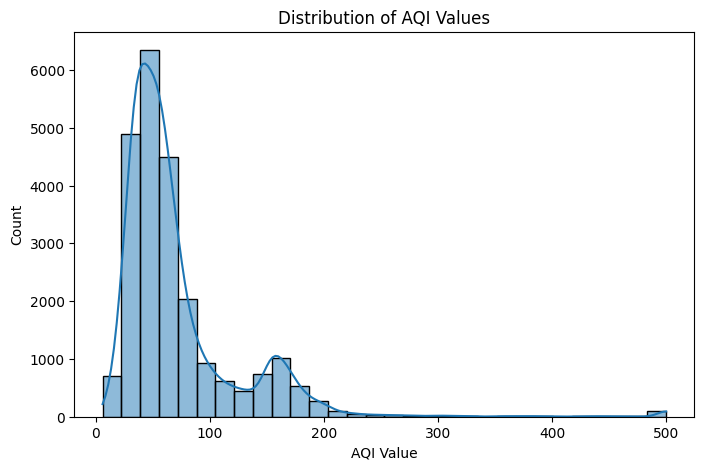

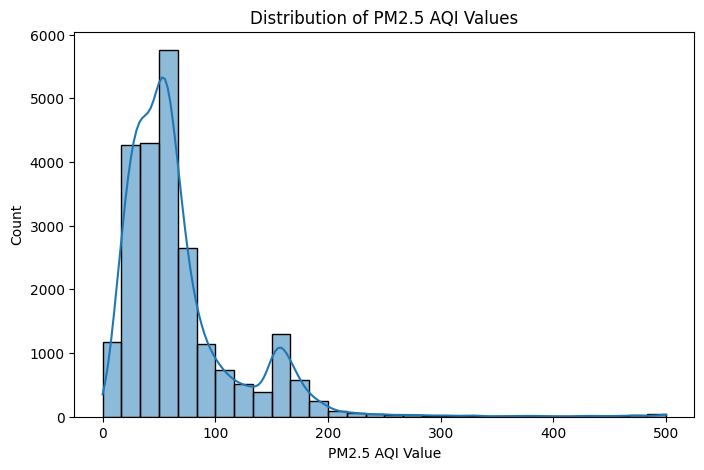

In [ ]:
# AQI Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['AQI Value'], bins=30, kde=True)
plt.title("Distribution of AQI Values")
plt.show()

# PM2.5 Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['PM2.5 AQI Value'], bins=30, kde=True)
plt.title("Distribution of PM2.5 AQI Values")
plt.show()

Most AQI values fall within low to moderate ranges, with some extreme values representing highly polluted conditions.

PM2.5 shows similar behavior, confirming the presence of severe pollution events.

### Step 9.4: Random Forest Model

We build a Random Forest classifier to predict AQI categories. This model can capture complex relationships between features.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 1.0

Confusion Matrix:
 [[1987    0    0    0    0    0]
 [   0   38    0    0    0    0]
 [   0    0 1846    0    0    0]
 [   0    0    0  446    0    0]
 [   0    0    0    0  318    0]
 [   0    0    0    0    0   58]]

Classification Report:
                                 precision    recall  f1-score   support

                          Good       1.00      1.00      1.00      1987
                     Hazardous       1.00      1.00      1.00        38
                      Moderate       1.00      1.00      1.00      1846
                     Unhealthy       1.00      1.00      1.00       446
Unhealthy for Sensitive Groups       1.00      1.00      1.00       318
                Very Unhealthy       1.00      1.00      1.00        58

                      accuracy                           1.00      4693
                     macro avg       1.00      1.00      1.00      4693
                  weighted avg       1.00      1.00      1.00      4693



### Step 9.5: Model Comparison

We compare the performance of Logistic Regression and Random Forest models using accuracy.

In [ ]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, accuracy_rf]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.999787
1,Random Forest,1.000000
